#### Case 1: Isobaric evaporation of liquid hydrogen in a 4.89 $m^3$ spherical tank experiments.

This notebook sets up the isobaric evaporation of liquid hydrogen ($LH_2$) in a 4.89 $m^3$ storage tank. A high liquid filling, high heat ingress scenario from Hasan (1991) is considered. This tank is representative of lab-scale tanks used for cryogen evaporation experiments that measure boil-off rates and thermal stratification.

In [2]:
# Ensure that python finds the submodules
import sys
sys.path.append("..") # Adds higher directory to python modules path.

# Scientific computing
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

## Module imports
# Import the storage tank Class
from cryoevap.storage_tanks import Tank

# Import Cryogen class
from cryoevap.cryogens import Cryogen

from scipy.integrate import simpson

#### Setup tank and cryogen properties

In [3]:
# LNG tank properties
Q_roof = 0 # Roof heat ingress / W
d_i = 1.26*2 # Internal diameter / m
d_o = d_i + 2.08e-3   # External diameter / m
T_air = 350 # Temperature of the environment K

# Set overall heat transfer coefficient through the walls for liquid and vapour
U_L = 0.01063 # W/m2/K
U_V = 0.01063 # W/m2/K
eta = 0.95

# Specify heat transfer rate at the bottom to prevent ground heating
Q_b = 0 # W, 
Q_roof = 0

# Spherical tank volume
V_tank      = 12.569 # m^3
Lenght_tank = 2.52   # m, length of the tank

# Initial liquid filling / Dimensionless
LF = 0.3

# Specify tank operating pressure
P = 117e3 # Pa

Geo_v1 = "horizontal"

Geo_l1 = "horizontal"

# Initialize large-scale tank
hor_tank = Tank(d_i, d_o, V_tank, Geo_v1, Geo_l1, LF, Lenght_tank)
hor_tank.set_HeatTransProps(U_L, U_V, T_air, Q_b, Q_roof, eta)
# Initialise cryogen
hydrogen1 = Cryogen(name = "hydrogen")
hydrogen1.set_coolprops(P)


# Set cryogen
hor_tank.cryogen = hydrogen1

# Calculate initial evaporation rate
# print("The initial evaporation rate of " + hydrogen1.name + " is %.1e kg/h" % (hor_tank.b_l_dot * 3600))

Calculate initial evaporation rate and transient period

In [4]:
# Calculate initial evaporation rate
print("The initial evaporation rate of " + hydrogen1.name + " is %.1e kg/h" % (hor_tank.b_l_dot * 3600))

# Estimate transient period duration
print("Transient period = %.3f s " % hor_tank.tau)

# Minimum number of hours to achieve steady state 
tau_h1 = (np.floor(hor_tank.tau / 3600) + 1)

# Print simulation time of the transient period for short-term storage
print("Simulation time: %.0i h" % tau_h1 )

# Calculate boil-off rate
BOR1 = (hor_tank.b_l_dot * 24 * 3600) / (hor_tank.V * hor_tank.LF * hor_tank.cryogen.rho_L)
print("BOR = %.3f %%" % (BOR1 * 100))

The initial evaporation rate of hydrogen is 8.2e-01 kg/h
Transient period = 69259.735 s 
Simulation time: 20 h
BOR = 7.425 %


#### Simulation setup and execution

In [5]:
# Define vertical spacing
dz = 0.0075

# Calculate number of nodes
n_z = 1 + int(np.round(hor_tank.l_V/dz, 0))

# Define dimensionless computational grid
hor_tank.z_grid = np.linspace(0, 1, n_z)

# Insulated roof
hor_tank.U_roof = 0

# Define evaporation time as twice as the transient period
#evap_time = 3600 *tau_h1*4
evap_time = 3600*24

# Time step to record data, relevant for plotting integrated quantities
# such as the vapour to liquid heat transfer rate, Q_VL
hor_tank.time_interval = 60

# Time step to plot each vapour temperature profile
hor_tank.plot_interval = evap_time/6

# Simulate the evaporation
hor_tank.evaporate(evap_time)

#### Visualisation of results

#### Vapour temperature

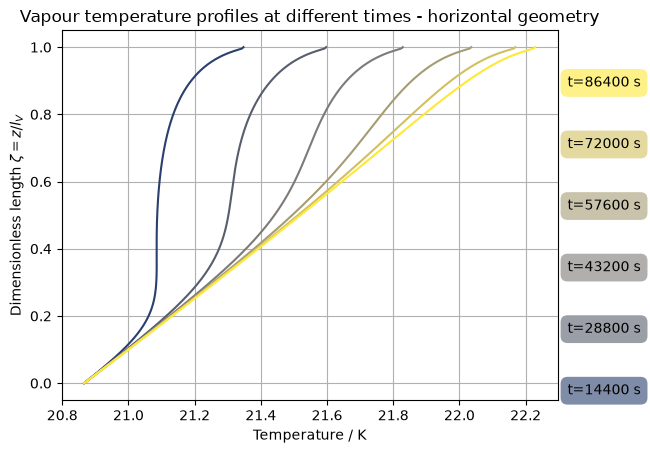

In [6]:
# Visualise the plot
hor_tank.plot_tv()

In [7]:
# hor_tank.plot_A_T()
# hor_tank.plot_l_L()
# hor_tank.plot_LF()
# hor_tank.plot_rho_V_avg()

Visualise liquid and vapour heat ingresses, $\dot{Q}_{\text{L}}$ and  $\dot{Q}_{\text{V}}$.

The plot also shows the vapour to liquid heat ingress, $\dot{Q}_{VL}$, and  the partition of the vapour heat ingress that is transferred to the interface by the wall directly, $\dot{Q}_{\text{V,w}}$

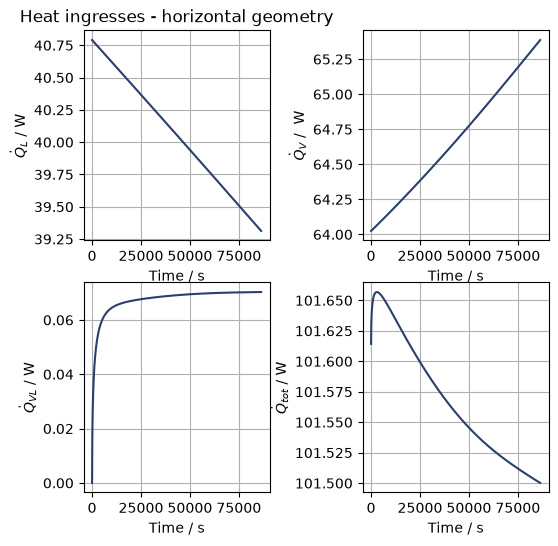

In [8]:
# Provide optional parameter unit to
# accommodate the scale of the experiment
hor_tank.plot_Q(unit="W")

#### Plot liquid volume

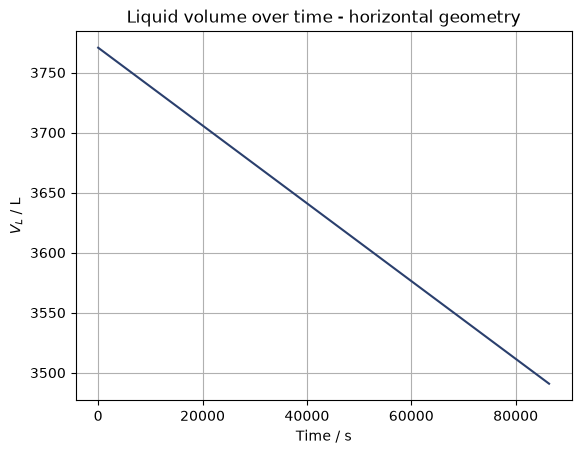

In [9]:
# Provide optional parameter unit to
# accommodate the scale of the experiment
hor_tank.plot_V_L(unit="L")

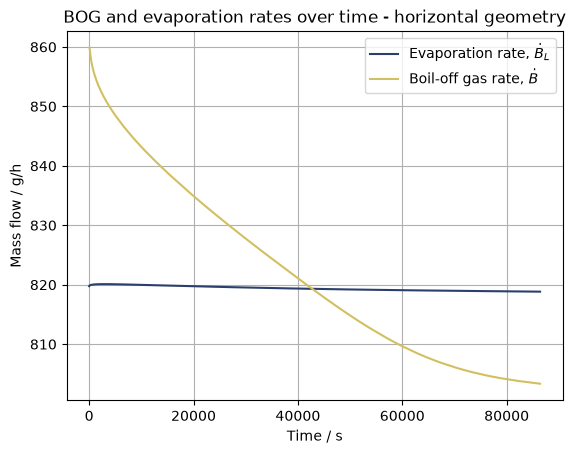

In [10]:
# Provide optional parameter unit to
# accommodate the scale of the experiment
hor_tank.plot_BOG(unit='g/h')

In [11]:
hor_tank.data["Pressure"] = np.ones_like(hor_tank.data["B_L"])*P
air = P*(V_tank*(1-LF))/(8.314*hydrogen1.T_sat)
for i in range(1,len(hor_tank.data["B_L"])):
    hor_tank.data["Pressure"][i] = ((simpson(hor_tank.data["B_L"][:i])*(1000/2) +air)*8.314*hor_tank.data["Tv_avg"][i])/(V_tank - hor_tank.data["V_L"][i])

Optional: CSV data export

If evaporation data is intended to be post-processed in another software, it can be exported readily with the help of the Pandas package.

In [12]:
# Import pandas 
import pandas as pd

In [13]:
# Create dataframe from dictionary
df_evap = pd.DataFrame.from_dict(hor_tank.data)

# Save file to the current working directory
df_evap.to_csv('LN2_small_m3.csv')

# Show the first five columns of the dataframe in console
df_evap[-5:]

,Time,Tv_avg,rho_V_avg,Q_VL,Q_L,Q_V,V_L,B_L,BOG,drho_V_avg,dV_L,z,A_T,vz,LF,dTV_avg,Q_Vw,Pressure
1436,86160,21.450665,1.463950,0.070274,39.316972,65.382277,3.491636,0.000227,0.000223,-4.911189e-08,-0.000003,0.599917,5.409239,0.000028,0.277797,5.812662e-07,62.113163,119788.018814
1437,86220,21.450700,1.463947,0.070274,39.315930,65.383310,3.491441,0.000227,0.000223,-4.896334e-08,-0.000003,0.599896,5.409173,0.000028,0.277782,5.795025e-07,62.114144,119787.884846
1438,86280,21.450735,1.463944,0.070275,39.314889,65.384343,3.491247,0.000227,0.000223,-4.878595e-08,-0.000003,0.599874,5.409106,0.000028,0.277766,5.773762e-07,62.115126,119787.750342
1439,86340,21.450769,1.463941,0.070275,39.313847,65.385376,3.491053,0.000227,0.000223,-4.851951e-08,-0.000003,0.599853,5.409039,0.000028,0.277751,5.741316e-07,62.116107,119787.614976
1440,86400,21.450804,1.463938,0.070276,39.312805,65.386409,3.490859,0.000227,0.000223,-4.820265e-08,-0.000003,0.599831,5.408973,0.000028,0.277736,5.702537e-07,62.117089,119787.478323


In [14]:
df_evap['flux_v'] = df_evap["Q_V"]/(np.pi*d_i*(d_i-df_evap['z']))
df_evap['flux_l'] = df_evap["Q_L"]/(np.pi*d_i*(df_evap['z']))
df_evap['total_flux'] = (df_evap['Q_L']+df_evap['Q_V'])/(np.pi*d_i**2)
df_evap.head()
df_evap[-5:]

,Time,Tv_avg,rho_V_avg,Q_VL,Q_L,Q_V,V_L,B_L,BOG,drho_V_avg,...,z,A_T,vz,LF,dTV_avg,Q_Vw,Pressure,flux_v,flux_l,total_flux
1436,86160,21.450665,1.463950,0.070274,39.316972,65.382277,3.491636,0.000227,0.000223,-4.911189e-08,...,0.599917,5.409239,0.000028,0.277797,5.812662e-07,62.113163,119788.018814,4.301201,8.278245,5.247985
1437,86220,21.450700,1.463947,0.070274,39.315930,65.383310,3.491441,0.000227,0.000223,-4.896334e-08,...,0.599896,5.409173,0.000028,0.277782,5.795025e-07,62.114144,119787.884846,4.301220,8.278322,5.247985
1438,86280,21.450735,1.463944,0.070275,39.314889,65.384343,3.491247,0.000227,0.000223,-4.878595e-08,...,0.599874,5.409106,0.000028,0.277766,5.773762e-07,62.115126,119787.750342,4.301240,8.278400,5.247984
1439,86340,21.450769,1.463941,0.070275,39.313847,65.385376,3.491053,0.000227,0.000223,-4.851951e-08,...,0.599853,5.409039,0.000028,0.277751,5.741316e-07,62.116107,119787.614976,4.301260,8.278477,5.247984
1440,86400,21.450804,1.463938,0.070276,39.312805,65.386409,3.490859,0.000227,0.000223,-4.820265e-08,...,0.599831,5.408973,0.000028,0.277736,5.702537e-07,62.117089,119787.478323,4.301280,8.278555,5.247984


In [15]:
df_evap.head()

,Time,Tv_avg,rho_V_avg,Q_VL,Q_L,Q_V,V_L,B_L,BOG,drho_V_avg,...,z,A_T,vz,LF,dTV_avg,Q_Vw,Pressure,flux_v,flux_l,total_flux
0,0,20.866191,1.517291,-2.317153e-14,40.790779,64.024782,3.770700,0.000228,0.000228,0.000000,...,0.630460,5.500947,0.000028,0.300000,0.000000,60.823543,117000.000000,4.279980,8.172477,5.253815
1,60,20.867341,1.517182,1.150669e-02,40.789767,64.025570,3.770506,0.000228,0.000239,-0.000002,...,0.630439,5.500886,0.000028,0.299985,0.000019,60.824291,117003.860206,4.279985,8.172547,5.253804
2,120,20.868472,1.517072,1.691632e-02,40.788756,64.026362,3.770311,0.000228,0.000239,-0.000002,...,0.630418,5.500825,0.000028,0.299969,0.000019,60.825043,117009.859157,4.279990,8.172617,5.253793
3,180,20.869590,1.516964,2.062054e-02,40.787744,64.027156,3.770117,0.000228,0.000239,-0.000002,...,0.630397,5.500764,0.000028,0.299954,0.000019,60.825798,117015.787945,4.279995,8.172687,5.253782
4,240,20.870698,1.516857,2.350456e-02,40.786732,64.027952,3.769922,0.000228,0.000238,-0.000002,...,0.630376,5.500702,0.000028,0.299938,0.000018,60.826554,117021.661635,4.280001,8.172757,5.253771


In [16]:
df_evap["SCHM BOG"] = ((df_evap["BOG"]*1000*3600/2)*(273+15)*8.314)/101325
df_evap[-5:]

,Time,Tv_avg,rho_V_avg,Q_VL,Q_L,Q_V,V_L,B_L,BOG,drho_V_avg,...,A_T,vz,LF,dTV_avg,Q_Vw,Pressure,flux_v,flux_l,total_flux,SCHM BOG
1436,86160,21.450665,1.463950,0.070274,39.316972,65.382277,3.491636,0.000227,0.000223,-4.911189e-08,...,5.409239,0.000028,0.277797,5.812662e-07,62.113163,119788.018814,4.301201,8.278245,5.247985,9.492462
1437,86220,21.450700,1.463947,0.070274,39.315930,65.383310,3.491441,0.000227,0.000223,-4.896334e-08,...,5.409173,0.000028,0.277782,5.795025e-07,62.114144,119787.884846,4.301220,8.278322,5.247985,9.492399
1438,86280,21.450735,1.463944,0.070275,39.314889,65.384343,3.491247,0.000227,0.000223,-4.878595e-08,...,5.409106,0.000028,0.277766,5.773762e-07,62.115126,119787.750342,4.301240,8.278400,5.247984,9.492326
1439,86340,21.450769,1.463941,0.070275,39.313847,65.385376,3.491053,0.000227,0.000223,-4.851951e-08,...,5.409039,0.000028,0.277751,5.741316e-07,62.116107,119787.614976,4.301260,8.278477,5.247984,9.492219
1440,86400,21.450804,1.463938,0.070276,39.312805,65.386409,3.490859,0.000227,0.000223,-4.820265e-08,...,5.408973,0.000028,0.277736,5.702537e-07,62.117089,119787.478323,4.301280,8.278555,5.247984,9.492091


In [17]:
df_evap['vz_avg']

KeyError: 'vz_avg'

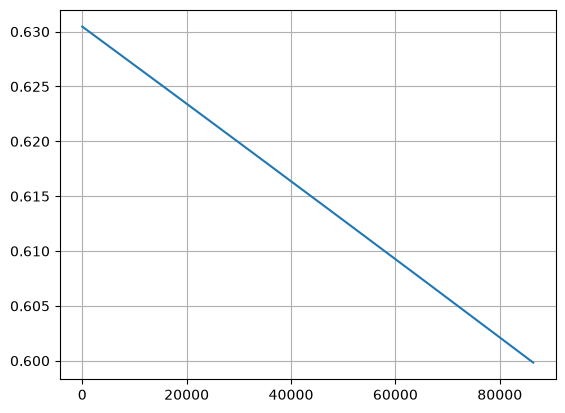

In [18]:
plt.plot(df_evap['Time'],df_evap['z'])
plt.grid(True)

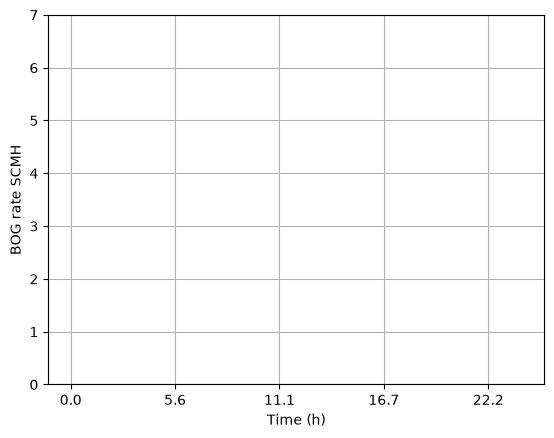

In [19]:
plt.plot(df_evap['Time'],df_evap['SCHM BOG'])
plt.ylim((0,7))
plt.ylabel('BOG rate SCMH')
plt.xlabel('Time (h)')
loc = plt.xticks()[0]
plt.xticks([round(i) for i in loc[1:-1]],[round(i/3600,1) for i in loc[1:-1]])
plt.grid(True)

#### References



Hasan, M., Lin, C. and Van Dresar, N. (1991). Self-Pressurization of a Flightweight Liquid Hydrogen Storage Tank Subjected to Low Heat Flux. [online] Available at: https://ntrs.nasa.gov/api/citations/19910011011/downloads/19910011011.pdf [Accessed 2 Jul. 2024].

Wang, Z. and Mérida, W. (2024). Thermal performance of cylindrical and spherical liquid hydrogen tanks. International Journal of Hydrogen Energy, 53, pp.667–683. doi:https://doi.org/10.1016/j.ijhydene.2023.11.287.